In [ ]:
# ── Core imports ───────────
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from wordcloud import STOPWORDS

warnings.filterwarnings("ignore")

# ── Dataset ────────────────
from datasets import load_dataset

# ── Plot style ─────────────
matplotlib.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── Constants ──────────────
CLASS_LABELS  = {0: "Hate Speech", 1: "Offensive", 2: "Normal"}
CLASS_COLORS  = {0: "#E74C3C",     1: "#F39C12",  2: "#2ECC71"}
PLOT_DIR      = "notebooks/plots/davidson"
os.makedirs(PLOT_DIR, exist_ok=True)

STOPWORDS = set(STOPWORDS)
STOPWORDS.update([
    "the","a","an","is","it","in","on","at","to","of","and","or",
    "but","not","s","t","rt","http","https","co","amp","gt","lt",
    "via","we","i","you","he","she","they","was","are","be"
])

In [4]:
ds = load_dataset("tdavidson/hate_speech_offensive")
df = ds["train"].to_pandas()

print(f"Loaded  : {len(df):,} rows")
print(f"Columns : {list(df.columns)}")
df.head(3)

Loaded  : 24,783 rows
Columns : ['count', 'hate_speech_count', 'offensive_language_count', 'neither_count', 'class', 'tweet']


,count,hate_speech_count,offensive_language_count,neither_count,class,tweet
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...


In [ ]:
# ── Feature engineering ────
# Vectorized text statistics
df["word_count"]  = df["tweet"].str.split().str.len()
df["char_count"]  = df["tweet"].str.len()

# Robust Twitter metadata extraction
df["is_retweet"]  = df["tweet"].str.contains(r"^\s*RT\b", case=False, regex=True).astype(int)
df["has_url"]     = df["tweet"].str.contains(r"https?://\S+", case=False, regex=True).astype(int)
df["has_mention"] = df["tweet"].str.contains(r"@\w+", regex=True).astype(int)
df["has_hashtag"] = df["tweet"].str.contains(r"#\w+", regex=True).astype(int)

# Vectorized Caps Ratio (handles empty tweets safely)
uppercase_counts  = df["tweet"].str.findall(r"[A-Z]").str.len()
df["caps_ratio"]   = uppercase_counts / df["char_count"].replace(0, 1)

# Vectorized Agreement Rate (using your exact Hugging Face column names)
vote_columns       = ["hate_speech_count", "offensive_language_count", "neither_count"]
max_votes          = df[vote_columns].max(axis=1)
df["agreement_rate"] = max_votes / df["count"].replace(0, 1)

# Label Mapping
df["class_label"]  = df["class"].map(CLASS_LABELS)

print(f"Feature columns added. DataFrame shape: {df.shape}")
df[["tweet", "class", "class_label", "word_count", "char_count", 
    "is_retweet", "has_url", "has_mention", "has_hashtag", 
    "caps_ratio", "agreement_rate"]].head(3)

Feature columns added. DataFrame shape: (24783, 15)


,tweet,class,class_label,word_count,char_count,is_retweet,has_url,has_mention,has_hashtag,caps_ratio,agreement_rate
0,!!! RT @mayasolovely: As a woman you shouldn't...,2,Normal,25,140,0,0,1,0,0.021429,1.0
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1,Offensive,16,85,0,0,1,0,0.023529,1.0
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1,Offensive,21,120,0,0,1,0,0.091667,1.0


In [ ]:
# ── Class counts & percentages ──
counts = df["class"].value_counts().sort_index()
pcts   = counts / counts.sum() * 100

print("Class distribution:")
for cls, cnt in counts.items():
    print(f"  {CLASS_LABELS[cls]:20s}: {cnt:6,}  ({pcts[cls]:.1f}%)")
print(f"\nImbalance ratio (max/min): {counts.max()/counts.min():.2f}x")

Class distribution:
  Hate Speech         :  1,430  (5.8%)
  Offensive           : 19,190  (77.4%)
  Normal              :  4,163  (16.8%)

Imbalance ratio (max/min): 13.42x


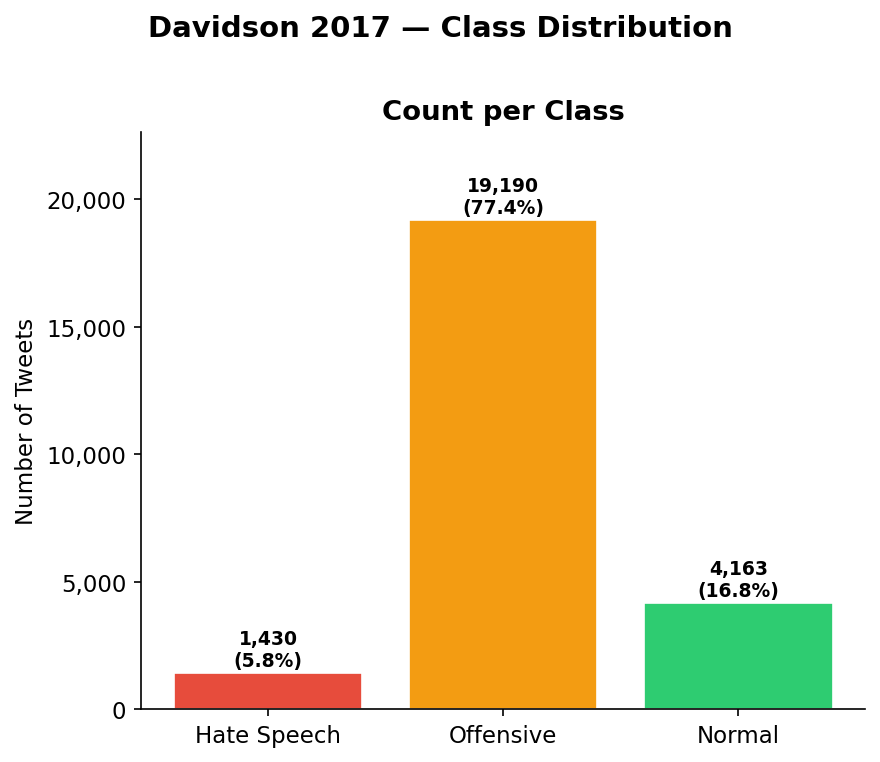

01_class_distribution.png


In [16]:
fig, axes = plt.subplots(1, 1, figsize=(6, 5))
fig.suptitle("Davidson 2017 — Class Distribution", fontsize=14, fontweight="bold", y=1.01)

colors = [CLASS_COLORS[c] for c in counts.index]
labels = [CLASS_LABELS[c] for c in counts.index]

# — Bar chart ——————————————————————————————————————————————————————————————————
ax = axes
bars = ax.bar(labels, counts.values, color=colors, edgecolor="white", linewidth=0.8)
for bar, cnt, pct in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 100,
            f"{cnt:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Count per Class", fontweight="bold")
ax.set_ylabel("Number of Tweets")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, counts.max() * 1.18)


plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/01_class_distribution.png", bbox_inches="tight")
plt.show()
print("01_class_distribution.png")

In [ ]:
# ── Per-class statistics ────
print(f"{'Class':<22} {'Mean WC':>8} {'Med WC':>8} {'95th WC':>9}  "
      f"{'Mean CC':>8} {'Med CC':>8} {'95th CC':>9}")
print("-" * 75)
for cls in [0, 1, 2]:
    sub = df[df["class"] == cls]
    print(f"{CLASS_LABELS[cls]:<22} "
          f"{sub['word_count'].mean():>8.1f} "
          f"{sub['word_count'].median():>8.1f} "
          f"{sub['word_count'].quantile(0.95):>9.1f}  "
          f"{sub['char_count'].mean():>8.1f} "
          f"{sub['char_count'].median():>8.1f} "
          f"{sub['char_count'].quantile(0.95):>9.1f}")

Class                   Mean WC   Med WC   95th WC   Mean CC   Med CC   95th CC
---------------------------------------------------------------------------
Hate Speech                13.9     13.5      26.0      84.6     82.0     146.0
Offensive                  14.0     13.0      26.0      83.5     78.0     146.0
Normal                     14.9     15.0      26.0      94.9     97.0     146.0


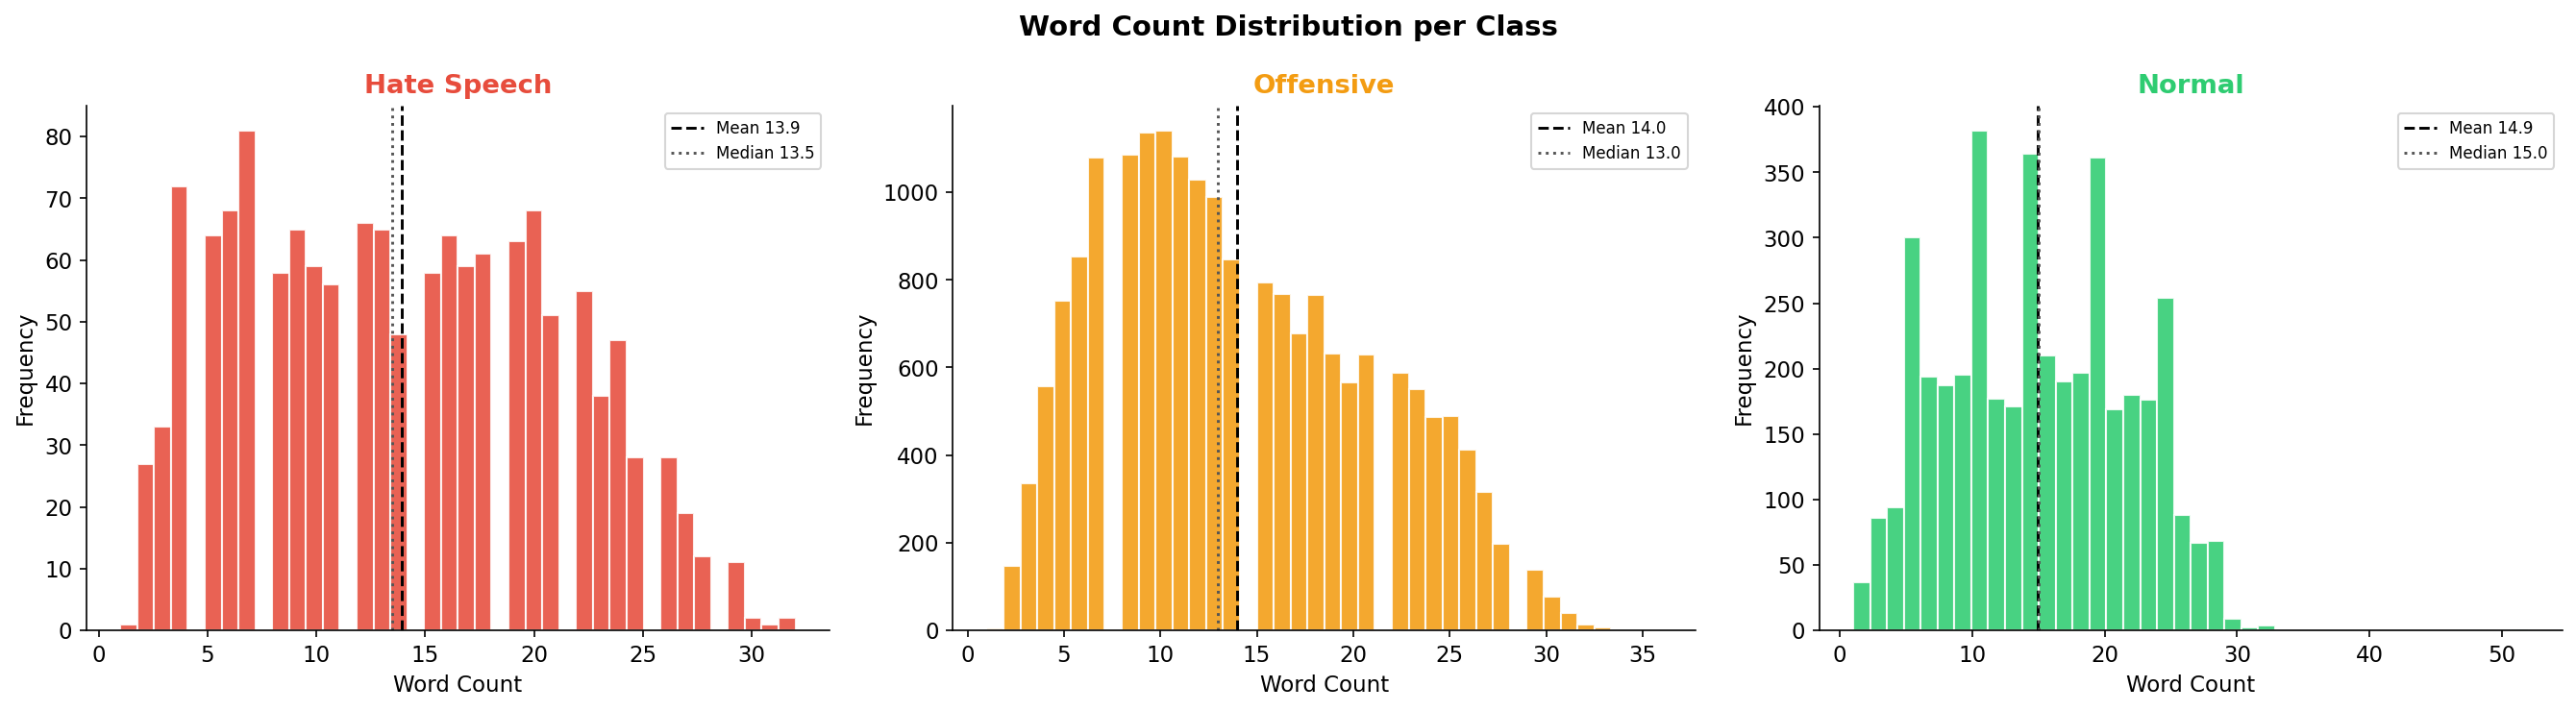

✓ Saved 02_word_count_histograms.png


In [ ]:
# ── Histograms per class ───
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Word Count Distribution per Class", fontsize=14, fontweight="bold")

for ax, cls in zip(axes, [0, 1, 2]):
    sub = df[df["class"] == cls]["word_count"]
    ax.hist(sub, bins=40, color=CLASS_COLORS[cls], edgecolor="white", alpha=0.88)
    ax.axvline(sub.mean(),   color="black",  ls="--", lw=1.4, label=f"Mean {sub.mean():.1f}")
    ax.axvline(sub.median(), color="#555555", ls=":",  lw=1.4, label=f"Median {sub.median():.1f}")
    ax.set_title(CLASS_LABELS[cls], fontweight="bold", color=CLASS_COLORS[cls])
    ax.set_xlabel("Word Count")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/02_word_count_histograms.png", bbox_inches="tight")
plt.show()
print("✓ Saved 02_word_count_histograms.png")

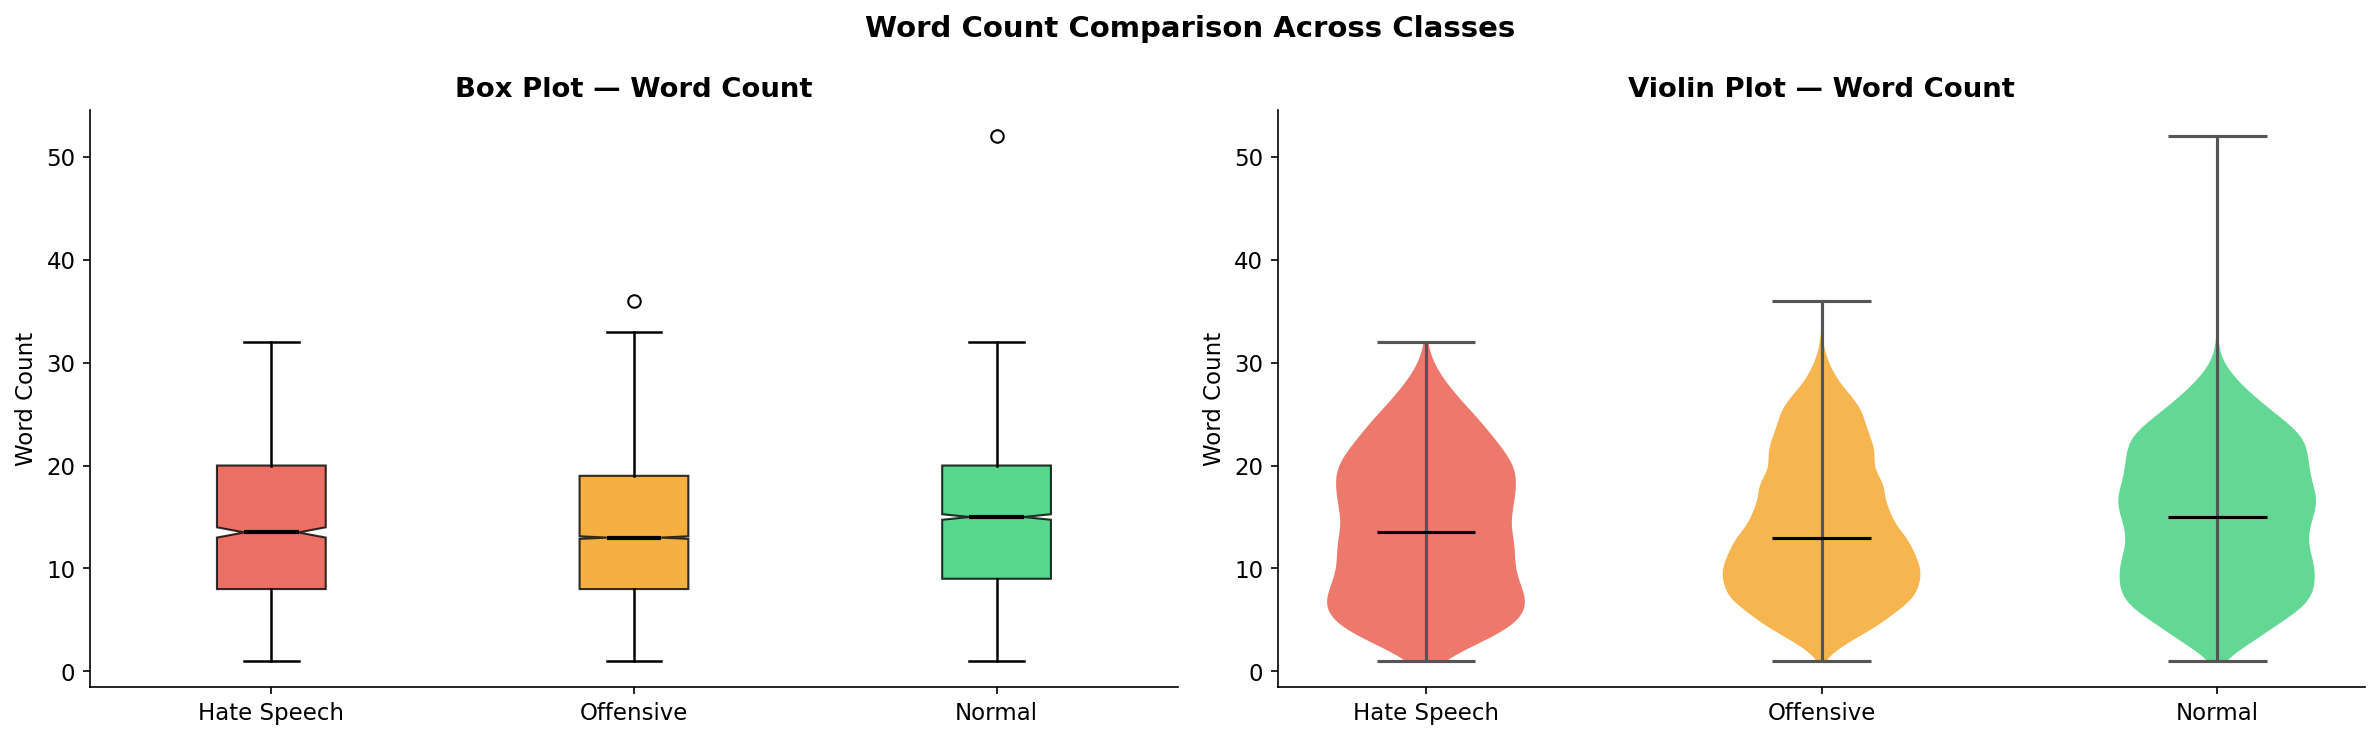

✓ Saved 03_word_count_box_violin.png


In [ ]:
# ── Box plot & Violin plot ─
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Word Count Comparison Across Classes", fontsize=14, fontweight="bold")

groups       = [df[df["class"] == c]["word_count"].values for c in [0, 1, 2]]
group_labels = [CLASS_LABELS[c] for c in [0, 1, 2]]
colors_list  = [CLASS_COLORS[c] for c in [0, 1, 2]]

# Box plot
ax = axes[0]
bp = ax.boxplot(groups, patch_artist=True, notch=True,
                medianprops=dict(color="black", lw=2),
                whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2))
for patch, color in zip(bp["boxes"], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xticklabels(group_labels)
ax.set_title("Box Plot — Word Count", fontweight="bold")
ax.set_ylabel("Word Count")

# Violin plot
ax = axes[1]
parts = ax.violinplot(groups, showmedians=True, showextrema=True)
for pc, color in zip(parts["bodies"], colors_list):
    pc.set_facecolor(color)
    pc.set_alpha(0.75)
parts["cmedians"].set_color("black")
parts["cbars"].set_color("#555555")
parts["cmaxes"].set_color("#555555")
parts["cmins"].set_color("#555555")
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(group_labels)
ax.set_title("Violin Plot — Word Count", fontweight="bold")
ax.set_ylabel("Word Count")

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/03_word_count_box_violin.png", bbox_inches="tight")
plt.show()
print("✓ Saved 03_word_count_box_violin.png")

In [ ]:
# ── Summary statistics ──────
full_agree = (df["agreement_rate"] == 1.0).mean() * 100
print(f"Mean agreement rate  : {df['agreement_rate'].mean():.3f}")
print(f"% full agreement     : {full_agree:.1f}%")
print(f"Mean raters per tweet: {df['count'].mean():.2f}")
print()
print("Mean agreement rate per class:")
for cls in [0, 1, 2]:
    sub = df[df["class"] == cls]["agreement_rate"]
    print(f"  {CLASS_LABELS[cls]:<22}: {sub.mean():.3f}")

Mean agreement rate  : 0.905
% full agreement     : 70.5%
Mean raters per tweet: 3.24

Mean agreement rate per class:
  Hate Speech           : 0.728
  Offensive             : 0.919
  Normal                : 0.899


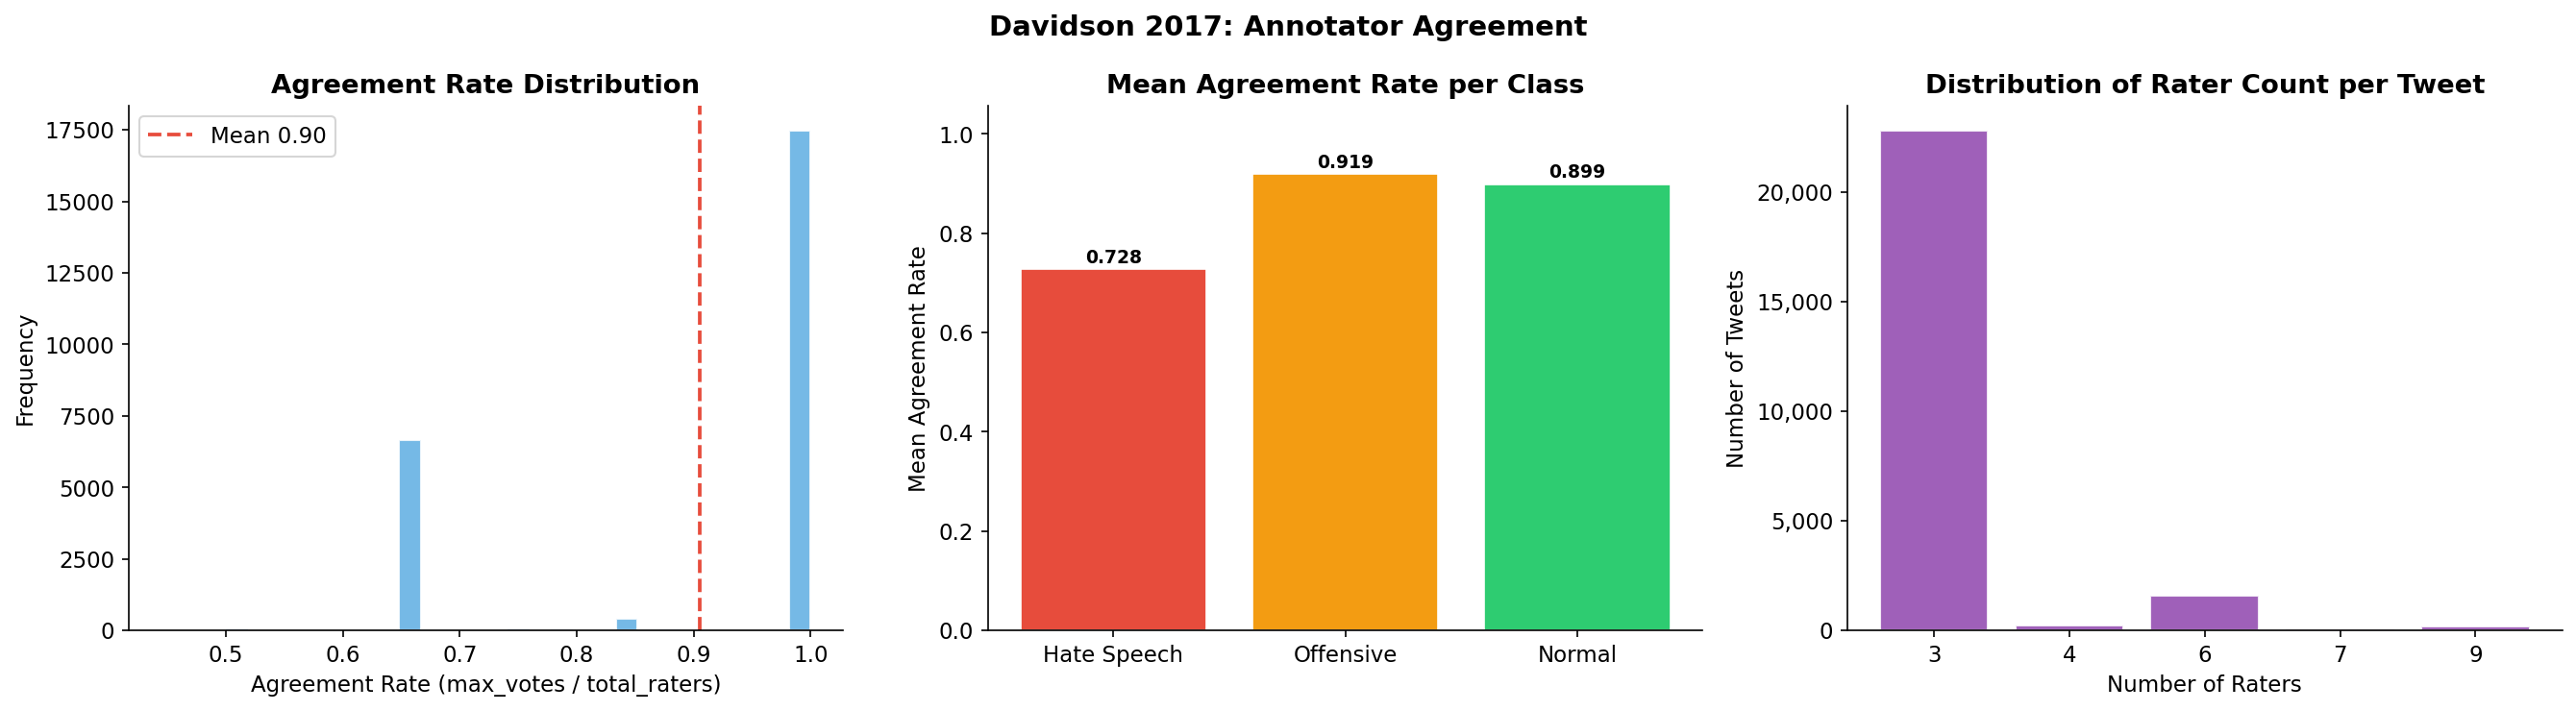

Saved 04_annotator_agreement.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Davidson 2017: Annotator Agreement", fontsize=14, fontweight="bold")

# — Histogram of agreement_rate ──
ax = axes[0]
ax.hist(df["agreement_rate"], bins=30, color="#5DADE2", edgecolor="white", alpha=0.85)
ax.axvline(df["agreement_rate"].mean(), color="#E74C3C", ls="--", lw=1.8,
           label=f"Mean {df['agreement_rate'].mean():.2f}")
ax.set_title("Agreement Rate Distribution", fontweight="bold")
ax.set_xlabel("Agreement Rate (max_votes / total_raters)")
ax.set_ylabel("Frequency")
ax.legend()

# — Mean agreement rate per class 
ax = axes[1]
mean_agree = [df[df["class"] == c]["agreement_rate"].mean() for c in [0, 1, 2]]
bars = ax.bar([CLASS_LABELS[c] for c in [0, 1, 2]], mean_agree,
              color=[CLASS_COLORS[c] for c in [0, 1, 2]],
              edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, mean_agree):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=9)
ax.set_title("Mean Agreement Rate per Class", fontweight="bold")
ax.set_ylabel("Mean Agreement Rate")
ax.set_ylim(0, max(mean_agree) * 1.15)

# — Rater count distribution 
ax = axes[2]
rater_counts = df["count"].value_counts().sort_index()
ax.bar(rater_counts.index.astype(str), rater_counts.values,
       color="#8E44AD", edgecolor="white", alpha=0.85)
ax.set_title("Distribution of Rater Count per Tweet", fontweight="bold")
ax.set_xlabel("Number of Raters")
ax.set_ylabel("Number of Tweets")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/04_annotator_agreement.png", bbox_inches="tight")
plt.show()
print("Saved 04_annotator_agreement.png")

In [24]:
def get_top_words(texts, n=15, stopwords=STOPWORDS):
    """Return top-n (word, count) tuples, excluding stopwords."""
    tokens = []
    for text in texts:
        for tok in re.sub(r"[^\w\s]", "", str(text).lower()).split():
            if tok not in stopwords and len(tok) > 1:
                tokens.append(tok)
    return Counter(tokens).most_common(n)

top_words = {cls: get_top_words(df[df["class"] == cls]["tweet"]) for cls in [0, 1, 2]}

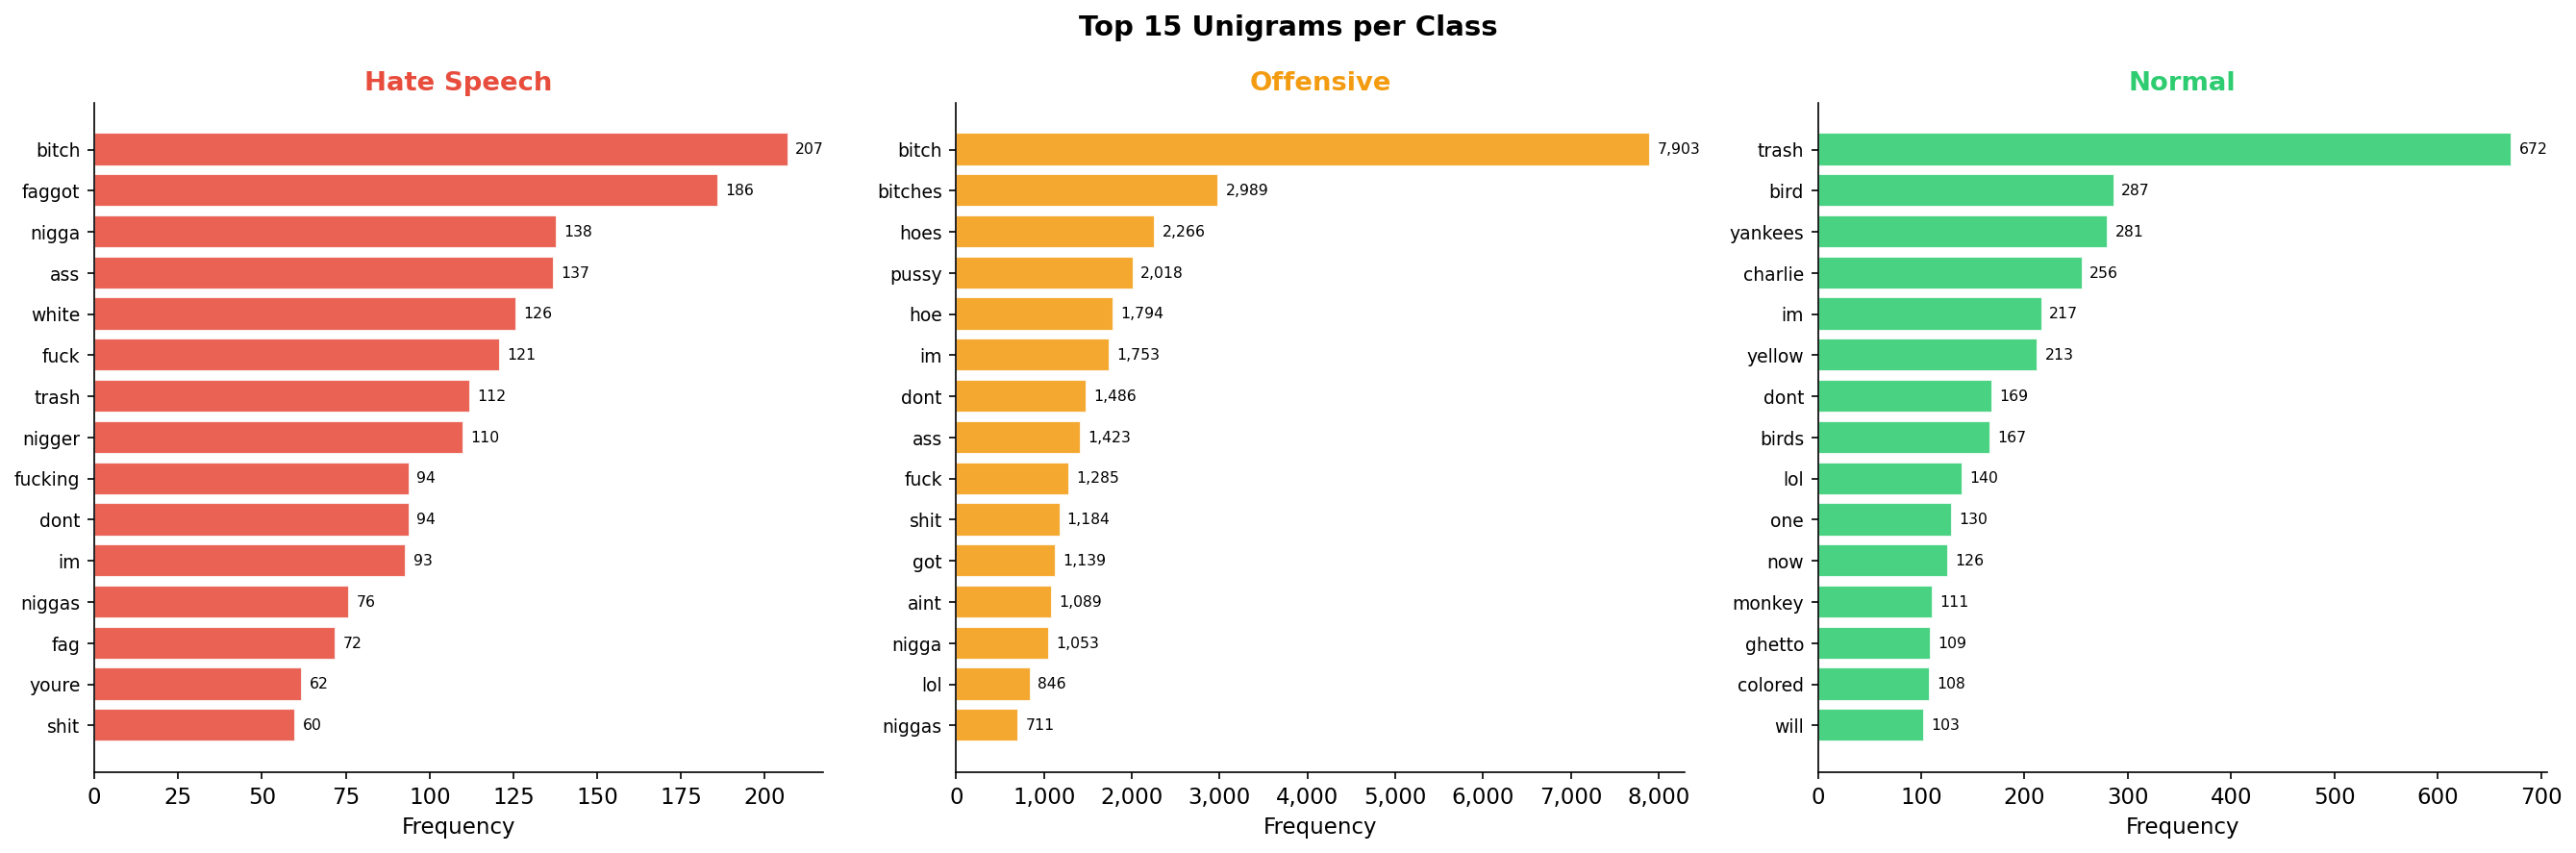

Saved 05_top_unigrams.png


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Top 15 Unigrams per Class",
             fontsize=14, fontweight="bold")

for ax, cls in zip(axes, [0, 1, 2]):
    words, freqs = zip(*top_words[cls])
    y_pos = np.arange(len(words))
    ax.barh(y_pos, freqs, color=CLASS_COLORS[cls], edgecolor="white", alpha=0.88)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(CLASS_LABELS[cls], fontweight="bold", color=CLASS_COLORS[cls])
    ax.set_xlabel("Frequency")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for i, v in enumerate(freqs):
        ax.text(v + freqs[0]*0.01, i, f"{v:,}", va="center", fontsize=7.5)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/05_top_unigrams.png", bbox_inches="tight")
plt.show()
print("Saved 05_top_unigrams.png")

In [ ]:
#  Data quality summary 
total        = len(df)
duplicates   = df["tweet"].duplicated().sum()
missing      = df["tweet"].isna().sum()
imbalance_r  = counts.max() / counts.min()
mean_raters  = df["count"].mean()
mean_agree   = df["agreement_rate"].mean()
full_agree_p = (df["agreement_rate"] == 1.0).mean() * 100

print("=" * 55)
print("  OCULA — Davidson 2017  |  Data Quality Summary")
print("=" * 55)
print(f"  Total tweets         : {total:>10,}")
print(f"  Duplicate tweets     : {duplicates:>10,}")
print(f"  Missing tweets       : {missing:>10,}")
print()
print("  Class Distribution:")
for cls in [0, 1, 2]:
    print(f"    {CLASS_LABELS[cls]:<20}: {counts[cls]:>6,}  ({pcts[cls]:.1f}%)")
print()
print(f"  Imbalance ratio      : {imbalance_r:>10.2f}x")
print(f"  Mean raters/tweet    : {mean_raters:>10.2f}")
print(f"  Mean agreement rate  : {mean_agree:>10.3f}")
print(f"  Full agreement (%)   : {full_agree_p:>10.1f}%")
print("=" * 55)

  OCULA — Davidson 2017  |  Data Quality Summary
  Total tweets         :     24,783
  Duplicate tweets     :          0
  Missing tweets       :          0

  Class Distribution:
    Hate Speech         :  1,430  (5.8%)
    Offensive           : 19,190  (77.4%)
    Normal              :  4,163  (16.8%)

  Imbalance ratio      :      13.42x
  Mean raters/tweet    :       3.24
  Mean agreement rate  :      0.905
  Full agreement (%)   :       70.5%
